# 04 - Offline Model Study (Bootstrap-Certified Analytics)

Research / analytical companion to `03_model_training.ipynb` (production training).

Trains a single CatBoost classifier with `posterior_sampling=True` (so the virtual-ensemble uncertainty pipeline in Phase 5 has what it needs) on a recent slice of the training window, caches predictions to disk, then runs a sequence of certified analytics with bootstrap CIs.

**Inputs**

- `data/model_dataset/dataset.parquet`
- `data/model_dataset/feature_list.json`

**Outputs**

- `data/model_dataset/research_predictions.parquet` (cache: k, ts, y, m_k, tau_k, phi, regime, p, split)
- `data/model_dataset/analytics/research_metrics_with_ci.json` (certified bundle)
- `data/model_dataset/analytics/research_metrics_by_regime.json`

Every analytics module lives under `src/analytics/`; the notebook is thin glue.


In [1]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
    if (ROOT.parent / "docs" / "MINIMAL_PROJECT_SPEC_v2.md").exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError("Could not locate repo root")
sys.path.insert(0, str(ROOT))

from src import utils
from src.analytics.bootstrap import BootstrapResult
from src.analytics.metrics import (
    bootstrap_all_metrics,
    bootstrap_metrics_by_regime,
    by_regime_to_summary_dict,
    to_summary_dict,
)
from src.analytics.fast_train import (
    TrainSliceConfig,
    compute_predictions,
    fit_research_model,
    research_train_params,
    save_predictions_cache,
    select_recent_train_slice,
)

DATASET_DIR = ROOT / "data" / "model_dataset"
DATASET_PATH = DATASET_DIR / "dataset.parquet"
FEATURE_LIST_PATH = DATASET_DIR / "feature_list.json"
ANALYTICS_DIR = DATASET_DIR / "analytics"
PLOTS_DIR = DATASET_DIR / "plots"
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)
print("ROOT       :", ROOT)
print("DATASET    :", DATASET_PATH)


ROOT       : C:\Users\vitil\OneDrive\Desktop\barrier_classifier
DATASET    : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\dataset.parquet


## 1. Configuration

All knobs for the study live in this cell. Change defaults here, re-run from this point.


In [2]:
# Train-slice config: keep only the most recent N months of train for fast iteration.
# Set months_back=None and frac_back=None to use the full training window.
TRAIN_SLICE = TrainSliceConfig(months_back=6.0)

# Bootstrap configuration for certified metrics.
BOOTSTRAP_B = 1000
BOOTSTRAP_CI = 0.95
BOOTSTRAP_STRATIFY = True   # preserve per-class counts across resamples
BOOTSTRAP_SEED = 0

# Regime signal (spec Section 11.4)
REGIME_SIGNAL = "vol__rs__f__w240"

# Output paths
RESEARCH_CACHE_PATH = DATASET_DIR / "research_predictions.parquet"
RESEARCH_METRICS_PATH = ANALYTICS_DIR / "research_metrics_with_ci.json"
RESEARCH_REGIME_PATH = ANALYTICS_DIR / "research_metrics_by_regime.json"

print(f"Train slice : months_back={TRAIN_SLICE.months_back}  frac_back={TRAIN_SLICE.frac_back}")
print(f"Bootstrap   : B={BOOTSTRAP_B}, CI={BOOTSTRAP_CI}, stratify={BOOTSTRAP_STRATIFY}, seed={BOOTSTRAP_SEED}")
print(f"Regime sig  : {REGIME_SIGNAL}")


Train slice : months_back=6.0  frac_back=None
Bootstrap   : B=1000, CI=0.95, stratify=True, seed=0
Regime sig  : vol__rs__f__w240


## 2. Load dataset and chronological split

Same chronological split + embargo as production (`utils.chronological_split_with_embargo`).
The full training window is shown for reference; the research model below trains on only a recent slice.


In [3]:
df = pd.read_parquet(DATASET_PATH)
feature_list = utils.load_json(FEATURE_LIST_PATH)
df = df.sort_values("k").reset_index(drop=True)

missing = [c for c in feature_list if c not in df.columns]
if missing:
    raise ValueError(f"feature_list missing in dataset: {missing[:10]} (total {len(missing)})")

train_df, val_df, test_df = utils.chronological_split_with_embargo(
    df, train_frac=utils.TRAIN_FRAC, val_frac=utils.VAL_FRAC, embargo_k=utils.EMBARGO_K,
)

# Defensive last-mile NaN handling. Spec requires no NaNs in feature columns
# (imputation done in 02_feature_building); fallback handles WIP dataset
# rebuilds where features leaked through unimputed. Two passes:
#   1. Drop columns with > 5% NaN in train (no useful train signal; can't be
#      imputed meaningfully because train median may itself be NaN).
#   2. Train-median impute the small-NaN remainder (no leakage from val/test).
# Operates on ALL feature-like columns (not just feature_list) because
# checkpoint_before_training validates every non-excluded column.
non_feature_cols = ["k", "ts", "y", "m_k", "tau_k", "phi", "w_dist", "w_time", "weight"]
feat_like = [c for c in train_df.columns if c not in non_feature_cols]

train_nan_frac = train_df[feat_like].isna().mean()
high_nan = train_nan_frac[train_nan_frac > 0.05].index.tolist()
if high_nan:
    print(f"Dropping {len(high_nan)} cols with >5% NaN in train: {high_nan}")
    for d in (train_df, val_df, test_df):
        d.drop(columns=high_nan, inplace=True)
    feature_list = [f for f in feature_list if f not in high_nan]

feat_like = [c for c in train_df.columns if c not in non_feature_cols]
remaining = [
    c for c in feat_like
    if train_df[c].isna().any() or val_df[c].isna().any() or test_df[c].isna().any()
]
if remaining:
    medians = train_df[remaining].median()
    for d in (train_df, val_df, test_df):
        d[remaining] = d[remaining].fillna(medians)
    print(f"Imputed {len(remaining)} cols with train-median: {remaining[:8]}{'...' if len(remaining) > 8 else ''}")

utils.checkpoint_before_training(train_df, val_df, test_df, embargo_k=utils.EMBARGO_K)

split_summary = pd.DataFrame([
    {"split": "train", "n": len(train_df), "ts_start": train_df["ts"].min(), "ts_end": train_df["ts"].max(), "base_rate": float(train_df["y"].mean())},
    {"split": "val",   "n": len(val_df),   "ts_start": val_df["ts"].min(),   "ts_end": val_df["ts"].max(),   "base_rate": float(val_df["y"].mean())},
    {"split": "test",  "n": len(test_df),  "ts_start": test_df["ts"].min(),  "ts_end": test_df["ts"].max(),  "base_rate": float(test_df["y"].mean())},
])
print(f"Total rows: {len(df):,}    Features: {len(feature_list):,}")
display(split_summary)


Dropping 8 cols with >5% NaN in train: ['opt_oi', 'put_open_interest', 'call_open_interest', 'opt_volume', 'put_volume', 'call_volume', 'pcr_oi', 'pcr_vol']


Imputed 6 cols with train-median: ['funding_rate', 'bvol', 'tb_ratio_fut', 'ret__rms__f__w3', 'ret__rms__f__w5', 'ret__rms__f__w6']
OK: Pre-training validation passed
  Train: 17,689 (70.3%)
  Val:   3,731 (14.8%)
  Test:  3,731 (14.8%)
Total rows: 25,271    Features: 1,251


,split,n,ts_start,ts_end,base_rate
0,train,17689,2025-01-15 00:01:00,2025-09-17 16:01:00,0.176324
1,val,3731,2025-09-18 12:21:00,2025-11-09 07:41:00,0.162691
2,test,3731,2025-11-10 04:01:00,2025-12-31 23:21:00,0.207183


## 3. Fit research model on recent train slice

Single seed, `posterior_sampling=True` (so virtual-ensemble uncertainty is available in Phase 5).
Iterations are capped high; early stopping does the work.

Learning curve is shown inline so it is observable mid-pipeline.


In [4]:
train_recent = select_recent_train_slice(train_df, TRAIN_SLICE)
print(f"Recent train slice : {len(train_recent):,} rows  ({train_recent['ts'].min()} -> {train_recent['ts'].max()})")
print(f"Slice base rate    : {train_recent['y'].mean():.4f}")

params = research_train_params(verbose=200)
print("\nResearch model params:")
for k, v in params.items():
    print(f"  {k}: {v}")

t0 = time.perf_counter()
model = fit_research_model(train_recent, val_df, feature_list, params=params)
fit_seconds = time.perf_counter() - t0
print(f"\nFit completed in {fit_seconds:.1f}s   best_iteration={model.get_best_iteration()}")


Recent train slice : 13,151 rows  (2025-03-19 00:41:00 -> 2025-09-17 16:01:00)
Slice base rate    : 0.1403

Research model params:
  iterations: 3000
  learning_rate: 0.01
  depth: 6
  l2_leaf_reg: 5.0
  loss_function: Logloss
  eval_metric: Logloss
  random_seed: 42
  early_stopping_rounds: 200
  border_count: 128
  thread_count: -1
  use_best_model: True
  allow_writing_files: False
  verbose: 200
  posterior_sampling: True


0:	learn: 0.6813177	test: 0.6823564	best: 0.6823564 (0)	total: 190ms	remaining: 9m 30s


200:	learn: 0.2476444	test: 0.2765252	best: 0.2765252 (200)	total: 6.93s	remaining: 1m 36s


400:	learn: 0.2339384	test: 0.2698303	best: 0.2698303 (400)	total: 13.6s	remaining: 1m 28s


600:	learn: 0.2255947	test: 0.2693553	best: 0.2692687 (573)	total: 21.1s	remaining: 1m 24s


Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.2692686756
bestIteration = 573

Shrink model to first 574 iterations.

Fit completed in 27.8s   best_iteration=573


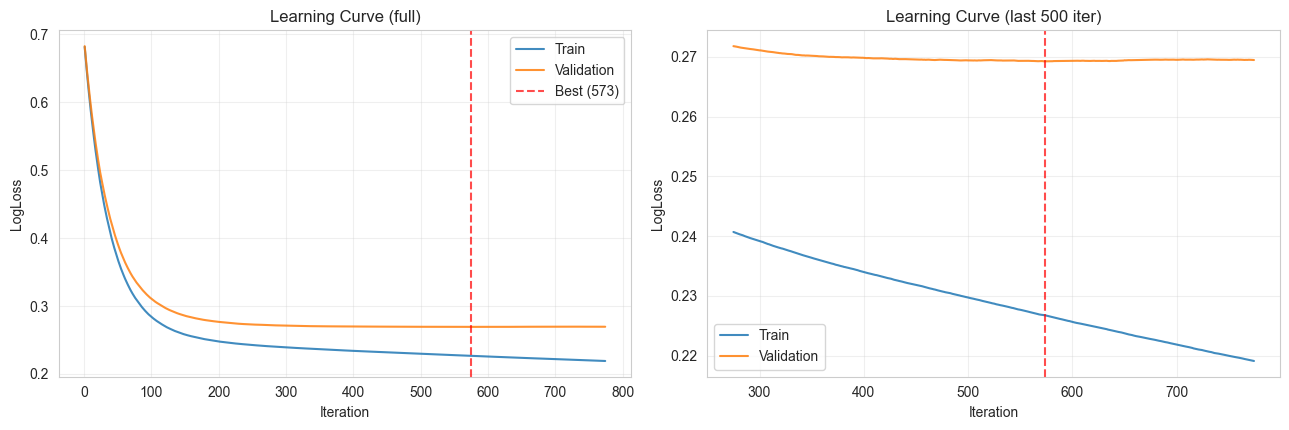

Final train LL : 0.2267
Final val   LL : 0.2693
Gap (val - tr) : +0.0425


In [5]:
# Learning curves (train + val LogLoss; full and zoomed)
evals = model.get_evals_result()
train_ll = evals.get("learn", {}).get("Logloss", [])
val_ll = evals.get("validation", evals.get("validation_0", {})).get("Logloss", [])

if train_ll and val_ll:
    iters = list(range(1, len(train_ll) + 1))
    best = int(model.get_best_iteration())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    axes[0].plot(iters, train_ll, label="Train", alpha=0.85)
    axes[0].plot(iters, val_ll, label="Validation", alpha=0.85)
    axes[0].axvline(best + 1, color="red", linestyle="--", alpha=0.7, label=f"Best ({best})")
    axes[0].set(xlabel="Iteration", ylabel="LogLoss", title="Learning Curve (full)")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    zoom = max(0, len(train_ll) - 500)
    axes[1].plot(iters[zoom:], train_ll[zoom:], label="Train", alpha=0.85)
    axes[1].plot(iters[zoom:], val_ll[zoom:], label="Validation", alpha=0.85)
    axes[1].axvline(best + 1, color="red", linestyle="--", alpha=0.7)
    axes[1].set(xlabel="Iteration", ylabel="LogLoss", title="Learning Curve (last 500 iter)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"Final train LL : {train_ll[best]:.4f}")
    print(f"Final val   LL : {val_ll[best]:.4f}")
    print(f"Gap (val - tr) : {val_ll[best] - train_ll[best]:+.4f}")
else:
    print("Could not extract learning curves; eval keys =", list(evals.keys()))


## 4. Compute and cache predictions

Predictions on val + test are saved to a parquet cache. **Every downstream analytics phase reads this cache** instead of retraining the model, so iteration on charts is essentially free.

Cache schema: `k, ts, y, m_k, tau_k, phi, regime, p, split`.


In [6]:
cache = compute_predictions(
    model,
    {"val": val_df, "test": test_df},
    feature_list,
    regime_signal_col=REGIME_SIGNAL,
)
save_predictions_cache(cache, RESEARCH_CACHE_PATH)
print(f"Saved cache : {RESEARCH_CACHE_PATH}  ({len(cache):,} rows)")

cache_summary = (
    cache.groupby("split")
    .agg(
        n=("p", "size"),
        base_rate=("y", "mean"),
        p_min=("p", "min"),
        p_med=("p", "median"),
        p_max=("p", "max"),
        regime_med=("regime", "median"),
    )
    .round(5)
)
display(cache_summary)


Saved cache : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\research_predictions.parquet  (7,462 rows)


,n,base_rate,p_min,p_med,p_max,regime_med
split,,,,,,
test,3731,0.20718,0.01043,0.11845,0.66333,0.0004
val,3731,0.16269,0.00973,0.07906,0.65750,0.0003


## 5. Certified core metrics with bootstrap CIs

The headline metrics (ROC-AUC, PR-AUC, log-loss, Brier, ECE) are bootstrapped class-stratified iid (preserves base rate). Reading order: **point** is the metric on the full split; **CI** is the bootstrap percentile interval at `BOOTSTRAP_CI`.

Pay attention to the **width of the CI on test PR-AUC** - that is exactly the uncertainty that the legacy notebook does not report.


In [7]:
val_cache = cache[cache["split"] == "val"].reset_index(drop=True)
test_cache = cache[cache["split"] == "test"].reset_index(drop=True)

print(f"Bootstrapping core metrics: B={BOOTSTRAP_B}, CI={BOOTSTRAP_CI}, stratify={BOOTSTRAP_STRATIFY} ...")
t0 = time.perf_counter()
val_metrics = bootstrap_all_metrics(
    val_cache["y"].to_numpy(), val_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
test_metrics = bootstrap_all_metrics(
    test_cache["y"].to_numpy(), test_cache["p"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
print(f"Bootstrap completed in {time.perf_counter() - t0:.1f}s")

def _ci(r: BootstrapResult) -> str:
    return f"[{r.ci_low:.4f}, {r.ci_high:.4f}]"
def _width(r: BootstrapResult) -> float:
    return float(r.ci_high - r.ci_low)

rows = []
for name in val_metrics:
    v, t = val_metrics[name], test_metrics[name]
    rows.append({
        "metric": name,
        "val (point)": v.point,
        "val 95% CI": _ci(v),
        "val width": _width(v),
        "test (point)": t.point,
        "test 95% CI": _ci(t),
        "test width": _width(t),
    })
metrics_table = pd.DataFrame(rows)
display(metrics_table.style.format({"val (point)": "{:.4f}", "val width": "{:.4f}", "test (point)": "{:.4f}", "test width": "{:.4f}"}))

bundle = {
    "config": {"B": BOOTSTRAP_B, "ci": BOOTSTRAP_CI, "stratify": BOOTSTRAP_STRATIFY, "seed": BOOTSTRAP_SEED, "regime_signal": REGIME_SIGNAL},
    "val": {"n_samples": int(len(val_cache)), "base_rate": float(val_cache["y"].mean()), **to_summary_dict(val_metrics)},
    "test": {"n_samples": int(len(test_cache)), "base_rate": float(test_cache["y"].mean()), **to_summary_dict(test_metrics)},
    "best_iteration": int(model.get_best_iteration()),
    "fit_seconds": float(fit_seconds),
    "train_slice": {
        "months_back": TRAIN_SLICE.months_back,
        "frac_back": TRAIN_SLICE.frac_back,
        "n_train": int(len(train_recent)),
        "ts_start": str(train_recent["ts"].min()),
        "ts_end": str(train_recent["ts"].max()),
    },
}
utils.save_json(RESEARCH_METRICS_PATH, bundle)
print(f"\nSaved certified metrics : {RESEARCH_METRICS_PATH}")


Bootstrapping core metrics: B=1000, CI=0.95, stratify=True ...


Bootstrap completed in 6.2s


,metric,val (point),val 95% CI,val width,test (point),test 95% CI,test width
0,roc_auc,0.7744,"[0.7548, 0.7933]",0.0385,0.7513,"[0.7313, 0.7693]",0.0380
1,pr_auc,0.4105,"[0.3774, 0.4497]",0.0723,0.4255,"[0.3957, 0.4579]",0.0622
2,log_loss,0.3884,"[0.3783, 0.3986]",0.0203,0.4560,"[0.4455, 0.4667]",0.0212
3,brier_score,0.1204,"[0.1178, 0.1231]",0.0053,0.1470,"[0.1438, 0.1501]",0.0063
4,ece_10bin,0.0509,"[0.0480, 0.0542]",0.0062,0.0577,"[0.0544, 0.0621]",0.0077



Saved certified metrics : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\research_metrics_with_ci.json


## 6. Per-regime certified metrics

Tercile breakdown by `vol__rs__f__w240`. The legacy analytics flagged that high-vol calibration is materially worse than low-vol; the bootstrap CIs let us judge whether that gap is real or sampling noise.

Two views:

1. Tabular: per (split, regime), point + CI for every metric.
2. Chart: ECE-by-regime barplot with CI error bars (val vs test side-by-side).


In [8]:
print("Bootstrapping metrics per volatility regime ...")
t0 = time.perf_counter()
val_by_regime = bootstrap_metrics_by_regime(
    val_cache["y"].to_numpy(), val_cache["p"].to_numpy(), val_cache["regime"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
test_by_regime = bootstrap_metrics_by_regime(
    test_cache["y"].to_numpy(), test_cache["p"].to_numpy(), test_cache["regime"].to_numpy(),
    B=BOOTSTRAP_B, ci=BOOTSTRAP_CI, stratify=BOOTSTRAP_STRATIFY, seed=BOOTSTRAP_SEED,
)
print(f"Per-regime bootstrap completed in {time.perf_counter() - t0:.1f}s")

def _regime_table(by_regime, split_name, cache_df):
    rows = []
    terciles = pd.qcut(cache_df["regime"], 3, labels=["low", "med", "high"])
    for label in ["low", "med", "high"]:
        if label not in by_regime:
            continue
        m = by_regime[label]
        mask = np.asarray(terciles == label)
        row = {
            "split": split_name,
            "regime": label,
            "n": int(mask.sum()),
            "base_rate": float(cache_df.loc[mask, "y"].mean()),
        }
        for name in ["roc_auc", "pr_auc", "brier_score", "ece_10bin"]:
            r = m.get(name)
            if r is None:
                continue
            row[f"{name}"] = r.point
            row[f"{name}_ci"] = f"[{r.ci_low:.4f}, {r.ci_high:.4f}]"
        rows.append(row)
    return pd.DataFrame(rows)

regime_table = pd.concat([
    _regime_table(val_by_regime, "val", val_cache),
    _regime_table(test_by_regime, "test", test_cache),
], ignore_index=True)
display(regime_table.style.format({"base_rate": "{:.4f}", "roc_auc": "{:.4f}", "pr_auc": "{:.4f}", "brier_score": "{:.4f}", "ece_10bin": "{:.4f}"}))


Bootstrapping metrics per volatility regime ...


Per-regime bootstrap completed in 11.2s


,split,regime,n,base_rate,roc_auc,roc_auc_ci,pr_auc,pr_auc_ci,brier_score,brier_score_ci,ece_10bin,ece_10bin_ci
0,val,low,1244,0.0490,0.6836,"[0.6185, 0.7531]",0.1202,"[0.0841, 0.1947]",0.0459,"[0.0452, 0.0466]",0.0184,"[0.0172, 0.0196]"
1,val,med,1243,0.1279,0.6805,"[0.6384, 0.7224]",0.2355,"[0.1999, 0.2958]",0.1082,"[0.1060, 0.1102]",0.0360,"[0.0336, 0.0434]"
2,val,high,1244,0.3111,0.6697,"[0.6376, 0.7028]",0.4879,"[0.4495, 0.5337]",0.2072,"[0.2014, 0.2128]",0.0993,"[0.0938, 0.1063]"
3,test,low,1244,0.0699,0.6937,"[0.6369, 0.7459]",0.1341,"[0.1088, 0.1867]",0.0639,"[0.0627, 0.0651]",0.0238,"[0.0223, 0.0317]"
4,test,med,1243,0.1979,0.6666,"[0.6311, 0.7012]",0.3335,"[0.2907, 0.3871]",0.1546,"[0.1511, 0.1582]",0.0637,"[0.0607, 0.0712]"
5,test,high,1244,0.3537,0.6464,"[0.6144, 0.6798]",0.4902,"[0.4553, 0.5334]",0.2225,"[0.2166, 0.2283]",0.0873,"[0.0823, 0.0975]"


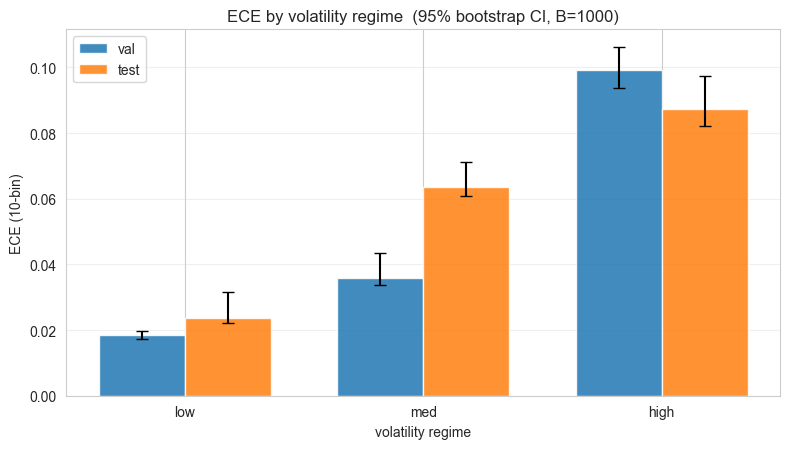

Saved per-regime metrics : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\research_metrics_by_regime.json
Saved chart              : C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\research_ece_by_regime.png


In [9]:
# ECE-by-regime barplot with bootstrap CI error bars (val vs test)
regimes = ["low", "med", "high"]
x = np.arange(len(regimes))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4.6))
for i, (split, by_regime) in enumerate([("val", val_by_regime), ("test", test_by_regime)]):
    points, lo_err, hi_err = [], [], []
    for r in regimes:
        if r not in by_regime or "ece_10bin" not in by_regime[r]:
            points.append(np.nan); lo_err.append(0.0); hi_err.append(0.0); continue
        m = by_regime[r]["ece_10bin"]
        points.append(m.point)
        lo_err.append(max(0.0, m.point - m.ci_low))
        hi_err.append(max(0.0, m.ci_high - m.point))
    ax.bar(x + (i - 0.5) * width, points, width=width, yerr=[lo_err, hi_err], capsize=4, label=split, alpha=0.85)
ax.set(xticks=x, xticklabels=regimes, ylabel="ECE (10-bin)", xlabel="volatility regime",
       title=f"ECE by volatility regime  (95% bootstrap CI, B={BOOTSTRAP_B})")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "research_ece_by_regime.png", dpi=150)
plt.show()

regime_bundle = {
    "val": by_regime_to_summary_dict(val_by_regime),
    "test": by_regime_to_summary_dict(test_by_regime),
}
utils.save_json(RESEARCH_REGIME_PATH, regime_bundle)
print(f"Saved per-regime metrics : {RESEARCH_REGIME_PATH}")
print(f"Saved chart              : {PLOTS_DIR / 'research_ece_by_regime.png'}")


---
End of Phase 0 + Phase 1 deliverables.

Subsequent sections will land as the corresponding analytics phases are built:

- **Phase 2** `src/analytics/curves.py` -> ROC / PR / calibration curves with bootstrap quantile bands; `degradation.py` -> rolling metrics with CIs, Brier-Murphy decomposition, PSI/KS, ADWIN
- **Phase 3** `edge.py` -> Net-EV-per-trade vs trades-per-day curve with bands, Kelly-by-bin, partial-AUC
- **Phase 4** `cohorts.py` -> SHAP cohort decomposition (TP/FP/TN/FN), discriminative-SHAP
- **Phase 5** `uncertainty.py` -> virtual-ensemble MI / total / data entropy decomposition, (p, knowledge_unc) gating
- **Phase 6** `audits.py` -> label-shuffle, future-feature audit, time-block permutation, turnover, latency-budget, deflated Sharpe
